# Constraint projection vs. ITPO

Instead of refining the predicted acceleration with Adam (ITPO), project it onto a constraint set:

$$a = a_{nn} - J^\top (J J^\top)^{-1} r, \qquad r = g(x + v + a_{nn}) - c,\quad J = \partial g / \partial a$$

Methods compared, all at inference only on pretrained models:
- **proj momentum**: $\sum_i a_i = 0$ (linear, exact: subtract the mean acceleration)
- **proj pressure**: $P_{yy} = 0$ (scalar, 2 Gauss-Newton iterations)
- **proj force**: inequality $|F_{i}| \le \tau(\text{step})$ per particle and component. The residual is only the part outside the band, $r = F - \mathrm{clip}(F, -\tau, \tau)$, removed by damped Jacobi sweeps $a_i \leftarrow a_i + \omega H_{ii}^{-1} r_i$ with $H_{ii}$ the per-particle bond stiffness
- **ITPO**: the cascade uses the HEAD weights (`CASCADE_ITPO_WEIGHTS`), the bootstrapped simulator `itpo_weights.get_params`
- **ITPO hinge**: ITPO with the $\mathrm{mean}(F_y^2)$ term replaced by $\mathrm{mean}(\mathrm{relu}(|F| - \tau)^2)$, same tuned weights

$\tau$ is 1.5x the ground-truth force envelope of the training sims ($\nu \ge 0.1$) at each step.

Both the simulator cascade and the bootstrapped GNN simulator are tested. Both were trained on $\nu \ge 0.1$ only, so test sims with $\nu < 0.1$ measure generalization.

In [1]:
import os
import time
import warnings
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import r2_score
from torch_geometric.data import Data
from tqdm import tqdm

import barostat_parameters
import itpo_weights
from barostat_utils import (
    estimate_initial_box_vel_y_accurate,
    update_box_y_thermodynamic,
)
from constraint_projection_benchmark import CASCADE_ITPO_WEIGHTS
from graph_utils import get_correct_edge_attr, prepare_traj
from ift import specialized_rollout_implicit
from itpo_weights import DatasetType, ModelType
from pressure import compute_per_particle_forces, compute_virial_stress
from simulator_SA_cpu_test import Model as VelocityModel
from training_utils import freeze_normalizer
from utils import (
    build_velocity_graph_correction,
    calc_p_ratio_box_tensor,
    compute_combined_physics_loss,
    load_and_split_dataset,
    rollout_cascade,
    simulate_then_rollout,
    specialized_rollout_cascade,
)


In [2]:
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")  # required by deterministic cuBLAS

torch.manual_seed(0)
torch.use_deterministic_algorithms(True, warn_only=True)  # scatter-add backward is nondeterministic on CUDA

### Data

In [ ]:
poisson_buckets = [
    {"max": 0.1, "count": 300},             # P < 0.1
    {"min": 0.1, "max": 0.2, "count": 100}, # 0.1 <= P < 0.2
    {"min": 0.2, "count": 100}              # P >= 0.2
]

dataset_type = DatasetType.NodeOptimized
poisson_threshold = 0.1  # models were trained on nu >= 0.1 only
n_train_sims = 100
n_test_sims = 60
max_sim_len = 200

train_files, _, test_files = load_and_split_dataset(
    registry_path="./data/data_registry.csv",
    target_data_type=dataset_type,
    possion_buckets=poisson_buckets,
    split_ratios=(0.5, 0.25, 0.25),
    seed=42
)

train_data = [prepare_traj(torch.load(file, weights_only=False)[:max_sim_len], None, calc_angles=False) for file in tqdm(train_files, desc="train data")]
train_data = [sim for sim in train_data if calc_p_ratio_box_tensor(sim) >= poisson_threshold][:n_train_sims]
test_data = [prepare_traj(torch.load(file, weights_only=False)[:max_sim_len], None, calc_angles=False) for file in tqdm(test_files[:n_test_sims], desc="test data")]

print(f"Train data: {len(train_data)} sims with nu >= {poisson_threshold} (used only for the force bound).")
print(f"Test data:  {len(test_data)} sims.")

### Load pretrained models

In [ ]:
device = "cuda"
hidden_size = 128
mp_layers = 2
mlp = 3
epochs = 100

# Simulator cascade
model_save_path = os.path.join("./trained_models", f"{dataset_type}", "cascade", "refined")
n_models = len(os.listdir(model_save_path))

cascade = []
for h in tqdm(range(n_models)):
    n_graphs = max(1, h + 1)
    init_graph = build_velocity_graph_correction([test_data[0][i].cpu().detach() for i in range(n_graphs)], panic_at_positions=False).to(device)

    current_h_model = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
    current_h_model.load_checkpoint(os.path.join(model_save_path, f"model_refined_h{h}_nl{mp_layers}_mlp{mlp}_epochs{epochs}.pt"))
    current_h_model = freeze_normalizer(current_h_model)
    for param in current_h_model.parameters():
        param.requires_grad = False
    cascade.append(current_h_model)
print(f"Loaded cascade of {len(cascade)} pretrained models.")

# Bootstrapped GNN simulator
history = 3
init_graph = Data(x=torch.ones((100, history * 2)), edge_attr=torch.ones((100, 4)))
gnn_simulator = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
gnn_simulator.load_checkpoint(f"./new_trained_models/{dataset_type}/MST/checkpoint_epoch_120.pt")
gnn_simulator = freeze_normalizer(gnn_simulator)
for param in gnn_simulator.parameters():
    param.requires_grad = False

### Ground truth: which constraints hold?

- Momentum: $|\langle a \rangle| / a_{rms}$, the mean acceleration relative to the typical per-particle acceleration.
- Pressure: virial $P_{yy}$ (the quantity ITPO penalises).
- Forces: per-step max $|F_i|$ over the training sims, and the bound $\tau$ built from it.

In [ ]:
gt_momentum = []
gt_pyy = []
for sim in test_data:
    r0 = sim[0].edge_attr[:, -2]
    a = torch.stack([sim[t + 1].pos - 2 * sim[t].pos + sim[t - 1].pos for t in range(1, len(sim) - 1)])
    gt_momentum.append((a.mean(dim=1).norm(dim=-1) / a.pow(2).sum(dim=-1).mean(dim=1).sqrt()).numpy())
    gt_pyy.append(torch.stack([compute_virial_stress(g, r0=r0, lj_cutoff=None)[1] for g in sim]).numpy())

train_force_max = torch.stack([
    torch.stack([compute_per_particle_forces(g, r0=sim[0].edge_attr[:, -2], cutoff=None).abs().max() for g in sim])
    for sim in train_data
])
tau = (1.5 * train_force_max.max(dim=0).values).to(device)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.5), layout="constrained")
for m, p in zip(gt_momentum, gt_pyy):
    ax[0].plot(m, color="C0", alpha=0.2)
    ax[1].plot(p, color="C1", alpha=0.2)
for f in train_force_max:
    ax[2].plot(f, color="C2", alpha=0.2)
ax[0].plot(np.mean(gt_momentum, axis=0), color="black")
ax[1].plot(np.mean(gt_pyy, axis=0), color="black")
ax[2].plot(tau.cpu(), color="black", label=r"$\tau$")
ax[0].set_ylabel(r"$|\langle a \rangle| / a_{rms}$")
ax[1].set_ylabel(r"GT $P_{yy}$")
ax[2].set_ylabel(r"train GT max $|F_i|$")
ax[2].legend()
for a_ in ax:
    a_.set_xlabel("Step")
plt.show()

### Projection layer

`next_graph` is the same forward Euler + uniaxial compression + barostat sequence as the ITPO closure in `physical_inference_step`.
`constrained_rollout` is `rollout_cascade` with a `refine(a, make_graph, r0, step)` hook between the GNN and the integrator. The bootstrapped simulator goes through the same loop by passing `[gnn_simulator] * (history + 1)`: then it is always the active model and gets the last `history + 1` frames.

In [ ]:
def next_graph(a, curr_graph, prev_graph, box_delta_x, r0, box_vel_y, barostat_config):
    num_particles = curr_graph.num_nodes
    stride_dt = barostat_config["default_skip"] * barostat_config["dt"]

    # Forward Euler
    x_next = curr_graph.pos + (curr_graph.pos - prev_graph.pos) + a
    predicted_graph = Data(x=x_next, pos=x_next, edge_index=curr_graph.edge_index, edge_attr=curr_graph.edge_attr, box_tensor=curr_graph.box_tensor)

    # Uniaxial compression in x, barostat in y
    compressed_ly, new_vel_y = update_box_y_thermodynamic(
        positions=x_next,
        edge_index=curr_graph.edge_index,
        edge_attr=curr_graph.edge_attr,
        current_box=curr_graph.box_tensor,
        r0=r0.float(),
        box_vel_y=box_vel_y,
        W_y=barostat_config["C_coupling"] * num_particles * (stride_dt**2),
        damping=barostat_config["damping"] * num_particles * stride_dt,
        stride_dt=stride_dt,
        target_pressure=barostat_config["target_pressure"],
        temperature=barostat_config["temperature"],
    )
    predicted_graph.box_tensor = torch.stack([curr_graph.box_tensor[0] + box_delta_x, compressed_ly])
    predicted_graph.edge_attr = get_correct_edge_attr(predicted_graph, recompute_stiff=False, lj_params=None, panic_at_nontensor_box=True)

    return predicted_graph, new_vel_y


def constrained_rollout(models, rollout, num_steps, barostat_config, box_delta_x, box_vel_y, r0, refine):
    rollout = list(rollout)
    for _ in range(num_steps):
        active_model = models[min(len(rollout), len(models)) - 1]
        input_graph = build_velocity_graph_correction(rollout[-len(models):], panic_at_positions=False)
        curr_graph = rollout[-1]
        prev_graph = rollout[-2] if len(rollout) > 1 else rollout[-1]
        make_graph = lambda a: next_graph(a, curr_graph, prev_graph, box_delta_x, r0, box_vel_y, barostat_config)

        with torch.no_grad():
            a = active_model.output_normalizer.inverse(active_model(input_graph, is_training=False))
        a = refine(a, make_graph, r0, len(rollout))

        with torch.no_grad():
            predicted_graph, box_vel_y = make_graph(a)
        rollout.append(predicted_graph)
    return rollout


def refine_momentum(a, make_graph, r0, step):
    return a - a.mean(dim=0, keepdim=True)


def refine_pressure(a, make_graph, r0, step, iters=2):
    # Gauss-Newton projection onto P_yy(x_next) = 0
    for _ in range(iters):
        with torch.enable_grad():
            a = a.detach().requires_grad_(True)
            predicted_graph, _ = make_graph(a)
            residual = compute_virial_stress(predicted_graph, r0=r0, lj_cutoff=None)[1]
            (grad,) = torch.autograd.grad(residual, a)
        a = a.detach() - residual.detach() / grad.pow(2).sum() * grad
    return a


def bond_stiffness_diag(graph):
    # Longitudinal part of the harmonic bond Hessian, summed per particle: H_ii = sum_j 2 k_ij n_ij n_ij^T
    src, dst = graph.edge_index
    vec = graph.pos[dst] - graph.pos[src]
    vec = vec - torch.round(vec / graph.box_tensor) * graph.box_tensor
    n = vec / vec.norm(dim=1, keepdim=True)
    blocks = 2 * graph.edge_attr[:, -1, None, None] * n[:, :, None] * n[:, None, :]
    return torch.zeros(graph.num_nodes, 2, 2, device=blocks.device).index_add_(0, src, blocks)


def make_refine_force(tau, sweeps=5, omega=0.5):
    # Jacobi projection onto |F_i| <= tau: F(x + d) ~ F - H d, so d_i = H_ii^-1 r_i removes the out-of-band residual r
    def refine(a, make_graph, r0, step):
        with torch.no_grad():
            for _ in range(sweeps):
                predicted_graph, _ = make_graph(a)
                forces = compute_per_particle_forces(predicted_graph, r0=r0, cutoff=None)
                residual = forces - forces.clamp(-tau[step], tau[step])
                a = a + omega * (torch.linalg.pinv(bond_stiffness_diag(predicted_graph)) @ residual[:, :, None])[:, :, 0]
        return a
    return refine


def make_refine_itpo_hinge(tau, weights):
    # ITPO (anchor + energy + pressure) with the force term replaced by a hinge on |F_i| <= tau
    def refine(a_nn, make_graph, r0, step):
        a = torch.nn.Parameter(a_nn.clone())
        optimizer = torch.optim.Adam([a], lr=weights.learning_rate)
        for _ in range(weights.refinement_iterations):
            with torch.enable_grad():
                optimizer.zero_grad()
                predicted_graph, _ = make_graph(a)
                energy_loss, _, pressure_loss = compute_combined_physics_loss(predicted_graph, r0=r0, lj_cutoff=None, target_Pyy=0.0)
                forces = compute_per_particle_forces(predicted_graph, r0=r0, cutoff=None)
                hinge_loss = torch.relu(forces.abs() - tau[step]).pow(2).mean()
                loss = (
                    torch.mean((a - a_nn) ** 2)
                    + weights.lambda_energy * energy_loss
                    + weights.lambda_force * hinge_loss
                    + weights.lambda_pressure * pressure_loss
                )
                loss.backward()
            optimizer.step()
        return a.detach()
    return refine

### Run all methods

In [ ]:
rollout_steps = 50


def evaluate(rollout, sim, n_frames, elapsed):
    rollout = [g.to(device) for g in rollout[:n_frames]]
    r0 = sim[0].edge_attr[:, -2].to(device)
    return {
        "time": elapsed,
        "gt_p": calc_p_ratio_box_tensor(sim[:n_frames]).item(),
        "pred_p": calc_p_ratio_box_tensor(rollout).item(),
        "mse": [torch.nn.functional.mse_loss(rollout[i].pos.cpu(), sim[i].pos.cpu()).item() for i in range(n_frames)],
        "force_ratio": [(compute_per_particle_forces(g, r0=r0, cutoff=None).abs().max() / tau[i]).item() for i, g in enumerate(rollout)],
    }


def timed(fn):
    start = time.perf_counter()
    out = fn()
    return out, time.perf_counter() - start


results = {"cascade": {}, "bootstrapped": {}}

# Simulator cascade
barostat_config = barostat_parameters.node_optimizated
weights = CASCADE_ITPO_WEIGHTS  # HEAD weights, see constraint_projection_benchmark.py
mean_delta_x = np.mean([(sim[4].box_tensor[0] - sim[3].box_tensor[0]).item() for sim in test_data])
cascade_methods = {
    "default": lambda s, r0: rollout_cascade(cascade, s[0].cpu().detach(), rollout_steps, barostat_config, None, mean_delta_x, device),
    "ITPO": lambda s, r0: specialized_rollout_cascade(s[0].cpu().detach(), cascade, barostat_config, mean_delta_x, weights, rollout_steps, device),
    "proj momentum": lambda s, r0: constrained_rollout(cascade, [s[0].to(device)], rollout_steps, barostat_config, mean_delta_x, 0.0, r0, refine_momentum),
    "proj pressure": lambda s, r0: constrained_rollout(cascade, [s[0].to(device)], rollout_steps, barostat_config, mean_delta_x, 0.0, r0, refine_pressure),
    "proj force": lambda s, r0: constrained_rollout(cascade, [s[0].to(device)], rollout_steps, barostat_config, mean_delta_x, 0.0, r0, make_refine_force(tau)),
    "ITPO hinge": lambda s, r0: constrained_rollout(cascade, [s[0].to(device)], rollout_steps, barostat_config, mean_delta_x, 0.0, r0, make_refine_itpo_hinge(tau, weights)),
}
results["cascade"] = {name: [] for name in cascade_methods}
for sim_idx, sim in enumerate(tqdm(test_data, desc="cascade")):
    torch.manual_seed(sim_idx)
    r0 = sim[0].edge_attr[:, -2].to(device)
    for name, method in cascade_methods.items():
        rollout, elapsed = timed(lambda: method(sim, r0))
        results["cascade"][name].append(evaluate(rollout, sim, rollout_steps + 1, elapsed))

# Bootstrapped GNN simulator: default and ITPO use their own MD bootstrap, the projections share one bootstrap per sim
weights = itpo_weights.get_params(ModelType.GNNModel, dataset_type)
bootstrapped_names = ["default", "ITPO", "proj momentum", "proj pressure", "proj force", "ITPO hinge"]
results["bootstrapped"] = {name: [] for name in bootstrapped_names}
for sim_idx, sim in enumerate(tqdm(test_data, desc="bootstrapped")):
    torch.manual_seed(sim_idx)  # the MD bootstrap adds Langevin noise
    r0 = sim[0].edge_attr[:, -2].to(device)
    n_frames = rollout_steps + history + 1

    # Compute dumping period (N MD steps in 1 dump step)
    sim_strain = (sim[1].box.x - sim[-1].box.x) / sim[0].box.x
    dump_period = int(int(sim_strain / 1e-5 / 0.01) / len(sim)) + 1
    barostat_config = deepcopy(barostat_parameters.node_optimizated)
    barostat_config["default_skip"] = dump_period
    md_steps = dump_period * history + 1

    rollout, elapsed = timed(lambda: simulate_then_rollout(sim[0].cpu().detach(), gnn_simulator, history, barostat_config, None, md_steps, rollout_steps, device))
    results["bootstrapped"]["default"].append(evaluate(rollout, sim, n_frames, elapsed))
    rollout, elapsed = timed(lambda: specialized_rollout_implicit(sim[0].cpu().detach(), gnn_simulator, history, barostat_config, None, weights, md_steps, rollout_steps, device))
    results["bootstrapped"]["ITPO"].append(evaluate(rollout, sim, n_frames, elapsed))

    bootstrap, bootstrap_time = timed(lambda: [g.to(device) for g in simulate_then_rollout(sim[0].cpu().detach(), gnn_simulator, history, barostat_config, None, md_steps, 0, device)[: history + 1]])
    box_delta_x = bootstrap[-1].box_tensor[0] - bootstrap[-2].box_tensor[0]
    box_vel_y = estimate_initial_box_vel_y_accurate(bootstrap[-3], bootstrap[-2], bootstrap[-1], dump_period * barostat_config["dt"])
    refines = {
        "proj momentum": refine_momentum,
        "proj pressure": refine_pressure,
        "proj force": make_refine_force(tau),
        "ITPO hinge": make_refine_itpo_hinge(tau, weights),
    }
    for name, refine in refines.items():
        rollout, elapsed = timed(lambda: constrained_rollout([gnn_simulator] * (history + 1), bootstrap, rollout_steps + 1, barostat_config, box_delta_x, box_vel_y, r0, refine))
        results["bootstrapped"][name].append(evaluate(rollout, sim, n_frames, elapsed + bootstrap_time))

### Summary

In [ ]:
def r2_split(runs):
    gt = np.array([r["gt_p"] for r in runs])
    pred = np.array([r["pred_p"] for r in runs])
    inside = gt >= poisson_threshold
    return r2_score(gt, pred), r2_score(gt[inside], pred[inside]), r2_score(gt[~inside], pred[~inside])


for model_name, model_results in results.items():
    n_inside = sum(r["gt_p"] >= poisson_threshold for r in model_results["default"])
    print(f"\n{model_name}  ({n_inside} sims with nu >= {poisson_threshold}, {len(test_data) - n_inside} with nu < {poisson_threshold})")
    print(f"{'method':<14} {'R2 all':>7} {'R2 in':>7} {'R2 out':>7} {'final MSE':>10} {'max|F|/tau':>10} {'time [s]':>9}")
    for name, runs in model_results.items():
        r2_all, r2_in, r2_out = r2_split(runs)
        final_mse = np.mean([r["mse"][-1] for r in runs])
        force_ratio = np.mean([max(r["force_ratio"][1:]) for r in runs])
        elapsed = np.mean([r["time"] for r in runs])
        print(f"{name:<14} {r2_all:7.3f} {r2_in:7.3f} {r2_out:7.3f} {final_mse:10.2e} {force_ratio:10.2f} {elapsed:9.2f}")

### Plots

In [ ]:
method_names = list(results["cascade"])
fig, ax = plt.subplots(2, len(method_names), figsize=(2.6 * len(method_names), 5.4), layout="constrained", sharex=True, sharey=True)
for row, (model_name, model_results) in enumerate(results.items()):
    for col, name in enumerate(method_names):
        gt = np.array([r["gt_p"] for r in model_results[name]])
        pred = np.array([r["pred_p"] for r in model_results[name]])
        inside = gt >= poisson_threshold
        line = (gt.min() - 0.05, gt.max() + 0.05)
        ax[row][col].plot(line, line, color="black", linewidth=1, linestyle="--")
        ax[row][col].axvline(poisson_threshold, color="grey", linewidth=0.5)
        ax[row][col].scatter(gt[inside], pred[inside], s=6, color="C0", label="in range")
        ax[row][col].scatter(gt[~inside], pred[~inside], s=6, color="C3", label="out of range")
        r2_all, r2_in, r2_out = r2_split(model_results[name])
        ax[row][col].set_title(f"{model_name}: {name}\n$R^2$ in={r2_in:.2f} out={r2_out:.2f}", fontsize=8)
    ax[row][0].set_ylabel(r"$\nu_{pred}$")
for col in range(len(method_names)):
    ax[1][col].set_xlabel(r"$\nu_{gt}$")
ax[0][0].legend(fontsize=7)
ax[0][0].set_ylim(-0.5, 0.6)
plt.show()

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(14, 7), layout="constrained")
for row, (model_name, model_results) in enumerate(results.items()):
    names = list(model_results)
    x = np.arange(len(names))
    r2 = np.array([r2_split(model_results[n]) for n in names])
    ax[row][0].bar(x - 0.2, r2[:, 1], width=0.4, label=rf"$\nu \geq {poisson_threshold}$ (in range)")
    ax[row][0].bar(x + 0.2, r2[:, 2], width=0.4, label=rf"$\nu < {poisson_threshold}$ (out of range)")
    ax[row][0].set_xticks(x, names, rotation=30)
    ax[row][0].set_ylim(-1, 1)
    ax[row][0].set_ylabel(rf"{model_name}: $R^2(\nu)$")
    ax[row][0].legend(fontsize=7)

    for i, name in enumerate(names):
        ax[row][1].plot(np.mean([r["mse"] for r in model_results[name]], axis=0), label=name, color=f"C{i}")
        ax[row][2].plot(np.mean([r["force_ratio"] for r in model_results[name]], axis=0), label=name, color=f"C{i}")
    ax[row][2].axhline(1.0, color="black", linestyle="--", linewidth=1)
    ax[row][1].set_ylabel("Position MSE")
    ax[row][2].set_ylabel(r"max $|F_i| / \tau$")
    for a_ in ax[row][1:]:
        a_.set_xlabel("Frame")
        a_.set_yscale("log")
        a_.legend(fontsize=7)
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")
for i, (model_name, model_results) in enumerate(results.items()):
    names = list(model_results)
    ax[i].bar(names, [np.mean([r["time"] for r in model_results[n]]) for n in names], color=[f"C{j}" for j in range(len(names))])
    ax[i].set_title(model_name)
    ax[i].set_ylabel("Wall time per rollout [s]")
    ax[i].set_yscale("log")
    ax[i].tick_params(axis="x", rotation=30)
plt.show()

## Long rollouts (up to 200 steps)

Computed headlessly by `constraint_projection_benchmark.py` (one CSV per model in `constraint_projection_results/`); this section only loads and plots.
Metrics are recorded after 50, 100, 150 and 200 GNN steps.

- **ITPO**: cascade uses the HEAD weights (50 iters, lr 2.4e-6), bootstrapped uses `itpo_weights.get_params`
- **ITPO (current weights)**: cascade only, the working-copy `itpo_weights.get_params` entry
- **proj force**: margin sweep $\tau = c \cdot$ training-sim force envelope
- **ITPO + proj force**: ITPO refinement followed by the force projection at $c = 1$

In [4]:
results_dir = Path("constraint_projection_results")
poisson_threshold = 0.1

frames = []
for model_name in ("cascade", "bootstrapped"):
    path = results_dir / f"{model_name}.csv"
    if not path.exists():
        warnings.warn(f"{path} is missing, skipping {model_name}.")
        continue
    df = pd.read_csv(path)
    n_sims = df["sim"].nunique()
    print(f"{model_name}: {n_sims} sims")
    frames.append(df)
long_df = pd.concat(frames, ignore_index=True)
long_df["label"] = np.where(long_df["margin"].isna(), long_df["method"], long_df["method"] + " c=" + long_df["margin"].astype(str))


def summarize(group):
    inside = group["gt_p"] >= poisson_threshold
    return pd.Series({
        "R2 all": r2_score(group["gt_p"], group["pred_p"]),
        "R2 in": r2_score(group["gt_p"][inside], group["pred_p"][inside]),
        "R2 out": r2_score(group["gt_p"][~inside], group["pred_p"][~inside]),
        "MSE": group["mse"].mean(),
        "max|F|/env": group["max_force_ratio"].mean(),
        "time [s]": group["time"].mean(),
    })


summary = long_df.groupby(["model", "label", "step"]).apply(summarize, include_groups=False)
with pd.option_context("display.float_format", lambda v: f"{v:.3g}", "display.max_rows", 500):
    display(summary.unstack("step")[["R2 all", "R2 out", "MSE"]])

cascade: 60 sims
bootstrapped: 60 sims


R2 all                    R2 out          \
step                                    50    100   150   200     50      100   
model        label                                                              
bootstrapped ITPO                     0.966 0.967 0.942 0.918   0.773   0.801   
             ITPO + proj force c=1.0  0.983 0.967 0.941 0.917   0.891   0.801   
             default                  0.809 0.757 0.732 0.715  -0.302  -0.511   
             proj force c=0.25        0.789 0.908 0.935 0.947  -0.432   0.435   
             proj force c=0.5         0.963 0.994 0.995 0.994   0.747   0.967   
             proj force c=0.75        0.992 0.984 0.976 0.971   0.949   0.909   
             proj force c=1.0         0.986 0.962 0.946 0.935   0.909   0.771   
             proj force c=1.5         0.956 0.917 0.897 0.885   0.701   0.486   
             proj force c=10.0        0.814 0.763 0.738 0.722  -0.263  -0.472   
             proj force c=2.0         0.929 0.879 0.854 0.841   0.519   0.248   
             proj force c=3.0         0.892 0.837 0.807 0.789   0.262 -0.0142   
cascade      ITPO                     0.915 0.864 0.843 0.832   0.422   0.154   
             ITPO (current weights)   0.838 0.823 0.821 0.821  -0.105  -0.106   
             ITPO + proj force c=1.0  0.989 0.989 0.983 0.979   0.934   0.935   
             default                  0.847 0.773 0.745 0.729 -0.0407  -0.414   
             proj force c=0.25         0.75 0.898 0.927 0.939  -0.717   0.365   
             proj force c=0.5         0.904 0.976 0.986 0.989   0.346   0.858   
             proj force c=0.75        0.958  0.98 0.977 0.974   0.716   0.882   
             proj force c=1.0         0.963 0.961 0.951 0.944   0.754   0.764   
             proj force c=1.5         0.949 0.923 0.906 0.895   0.655   0.524   
             proj force c=10.0        0.859  0.79 0.763 0.748  0.0414  -0.308   
             proj force c=2.0         0.936 0.901 0.882 0.869   0.565   0.386   
             proj force c=3.0         0.918 0.872  0.85 0.837   0.443   0.206   

                                                          MSE           \
step                                     150     200      50       100   
model        label                                                       
bootstrapped ITPO                      0.662   0.527 8.38e-08 2.61e-07   
             ITPO + proj force c=1.0   0.654   0.518 6.82e-08 2.52e-07   
             default                  -0.617  -0.688 2.53e-07 1.19e-06   
             proj force c=0.25         0.618   0.695  1.1e-07 2.84e-07   
             proj force c=0.5          0.979   0.976 6.78e-08 2.71e-07   
             proj force c=0.75         0.863   0.836 8.91e-08 4.01e-07   
             proj force c=1.0           0.68   0.625 1.13e-07 5.24e-07   
             proj force c=1.5          0.382   0.323 1.48e-07    7e-07   
             proj force c=10.0        -0.582  -0.649 2.49e-07 1.17e-06   
             proj force c=2.0          0.123  0.0621 1.71e-07  8.1e-07   
             proj force c=3.0         -0.163  -0.249 1.97e-07 9.33e-07   
cascade      ITPO                      0.052 0.00321 1.65e-07 8.66e-07   
             ITPO (current weights)  -0.0793 -0.0662 2.56e-07 1.11e-06   
             ITPO + proj force c=1.0     0.9   0.876 1.38e-07 6.41e-07   
             default                   -0.54  -0.604 3.54e-07  1.8e-06   
             proj force c=0.25         0.563   0.645 1.92e-07 6.47e-07   
             proj force c=0.5          0.924   0.943 1.64e-07 6.56e-07   
             proj force c=0.75         0.871   0.853 1.77e-07  7.9e-07   
             proj force c=1.0          0.714   0.674 1.99e-07 9.24e-07   
             proj force c=1.5          0.438   0.385 2.32e-07 1.12e-06   
             proj force c=10.0         -0.43  -0.494 3.46e-07 1.75e-06   
             proj force c=2.0          0.294   0.232 2.53e-07 1.24e-06   
             proj force c=3.0          0.101  0.0362 2.81e-07 1.39e-06   

     

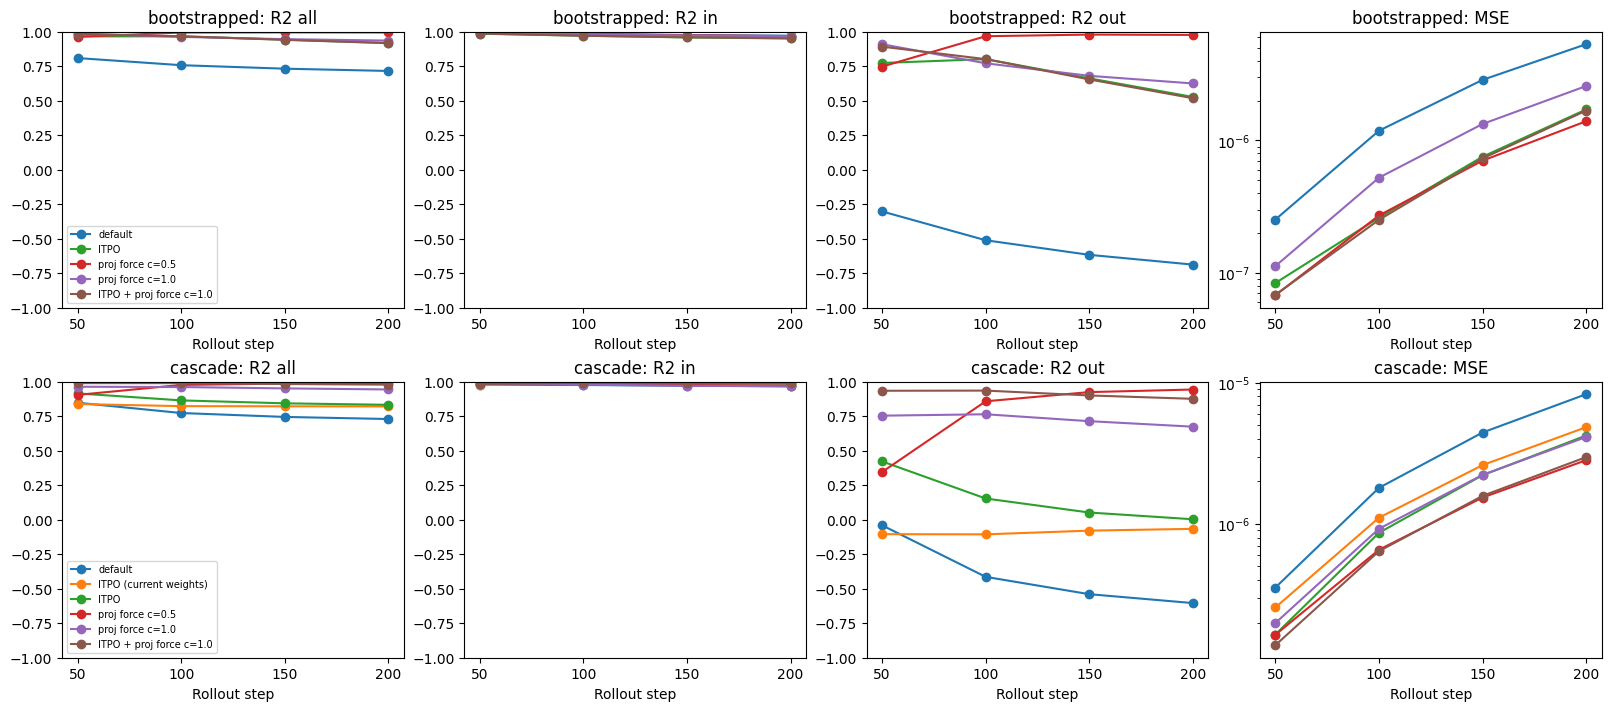

In [5]:
main_methods = ["default", "ITPO (current weights)", "ITPO", "proj force c=0.5", "proj force c=1.0", "ITPO + proj force c=1.0"]
models = list(summary.index.get_level_values("model").unique())

fig, ax = plt.subplots(len(models), 4, figsize=(16, 3.5 * len(models)), layout="constrained", squeeze=False)
for row, model_name in enumerate(models):
    for i, label in enumerate(main_methods):
        if (model_name, label) not in summary.index.droplevel("step"):
            continue
        s = summary.loc[(model_name, label)]
        for col, metric in enumerate(["R2 all", "R2 in", "R2 out", "MSE"]):
            ax[row][col].plot(s.index, s[metric], marker="o", label=label, color=f"C{i}")
    for col, metric in enumerate(["R2 all", "R2 in", "R2 out", "MSE"]):
        ax[row][col].set_title(f"{model_name}: {metric}")
        ax[row][col].set_xlabel("Rollout step")
        ax[row][col].set_xticks(sorted(long_df["step"].unique()))
    for col in range(3):
        ax[row][col].set_ylim(-1, 1)
    ax[row][3].set_yscale("log")
    ax[row][0].legend(fontsize=7)
plt.show()

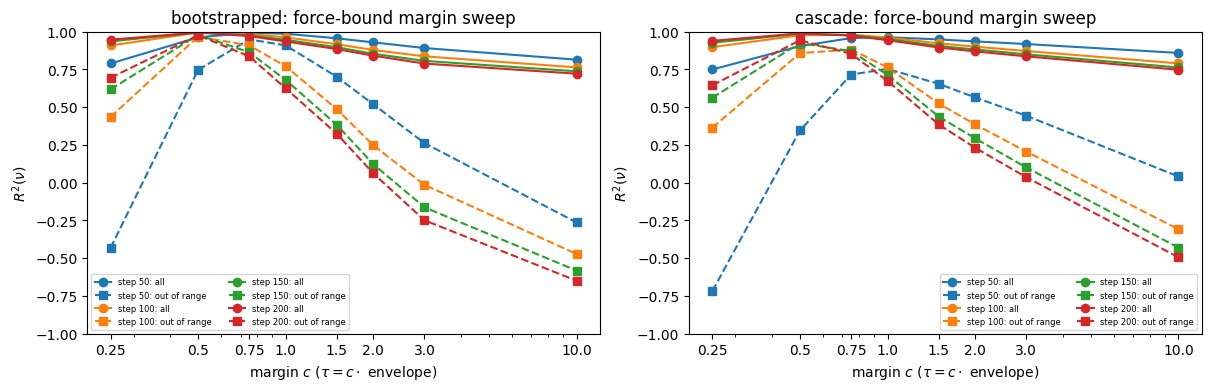

In [6]:
fig, ax = plt.subplots(1, len(models), figsize=(6 * len(models), 3.8), layout="constrained", squeeze=False)
for col, model_name in enumerate(models):
    sweep = long_df[(long_df["model"] == model_name) & (long_df["method"] == "proj force")]
    sweep_summary = sweep.groupby(["step", "margin"]).apply(summarize, include_groups=False)
    for i, step in enumerate(sorted(sweep["step"].unique())):
        s = sweep_summary.loc[step]
        ax[0][col].plot(s.index, s["R2 all"], marker="o", color=f"C{i}", label=f"step {step}: all")
        ax[0][col].plot(s.index, s["R2 out"], marker="s", linestyle="--", color=f"C{i}", label=f"step {step}: out of range")
    ax[0][col].set_xscale("log")
    ax[0][col].set_xticks(sorted(sweep["margin"].unique()), [str(m) for m in sorted(sweep["margin"].unique())])
    ax[0][col].set_ylim(-1, 1)
    ax[0][col].set_xlabel(r"margin $c$ ($\tau = c \cdot$ envelope)")
    ax[0][col].set_ylabel(r"$R^2(\nu)$")
    ax[0][col].set_title(f"{model_name}: force-bound margin sweep")
    ax[0][col].legend(fontsize=6, ncol=2)
plt.show()

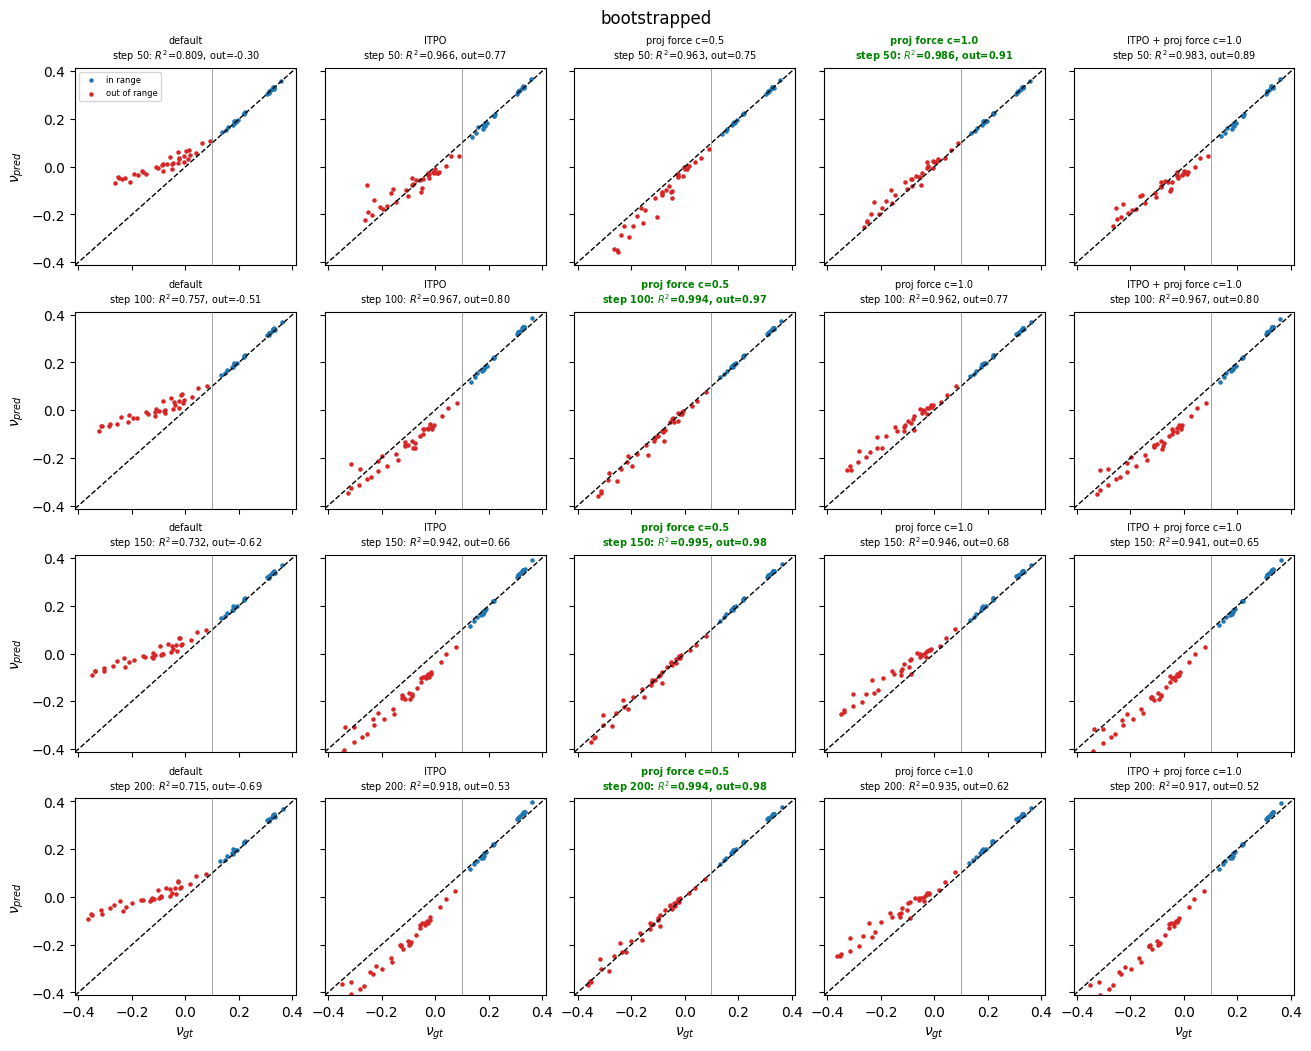

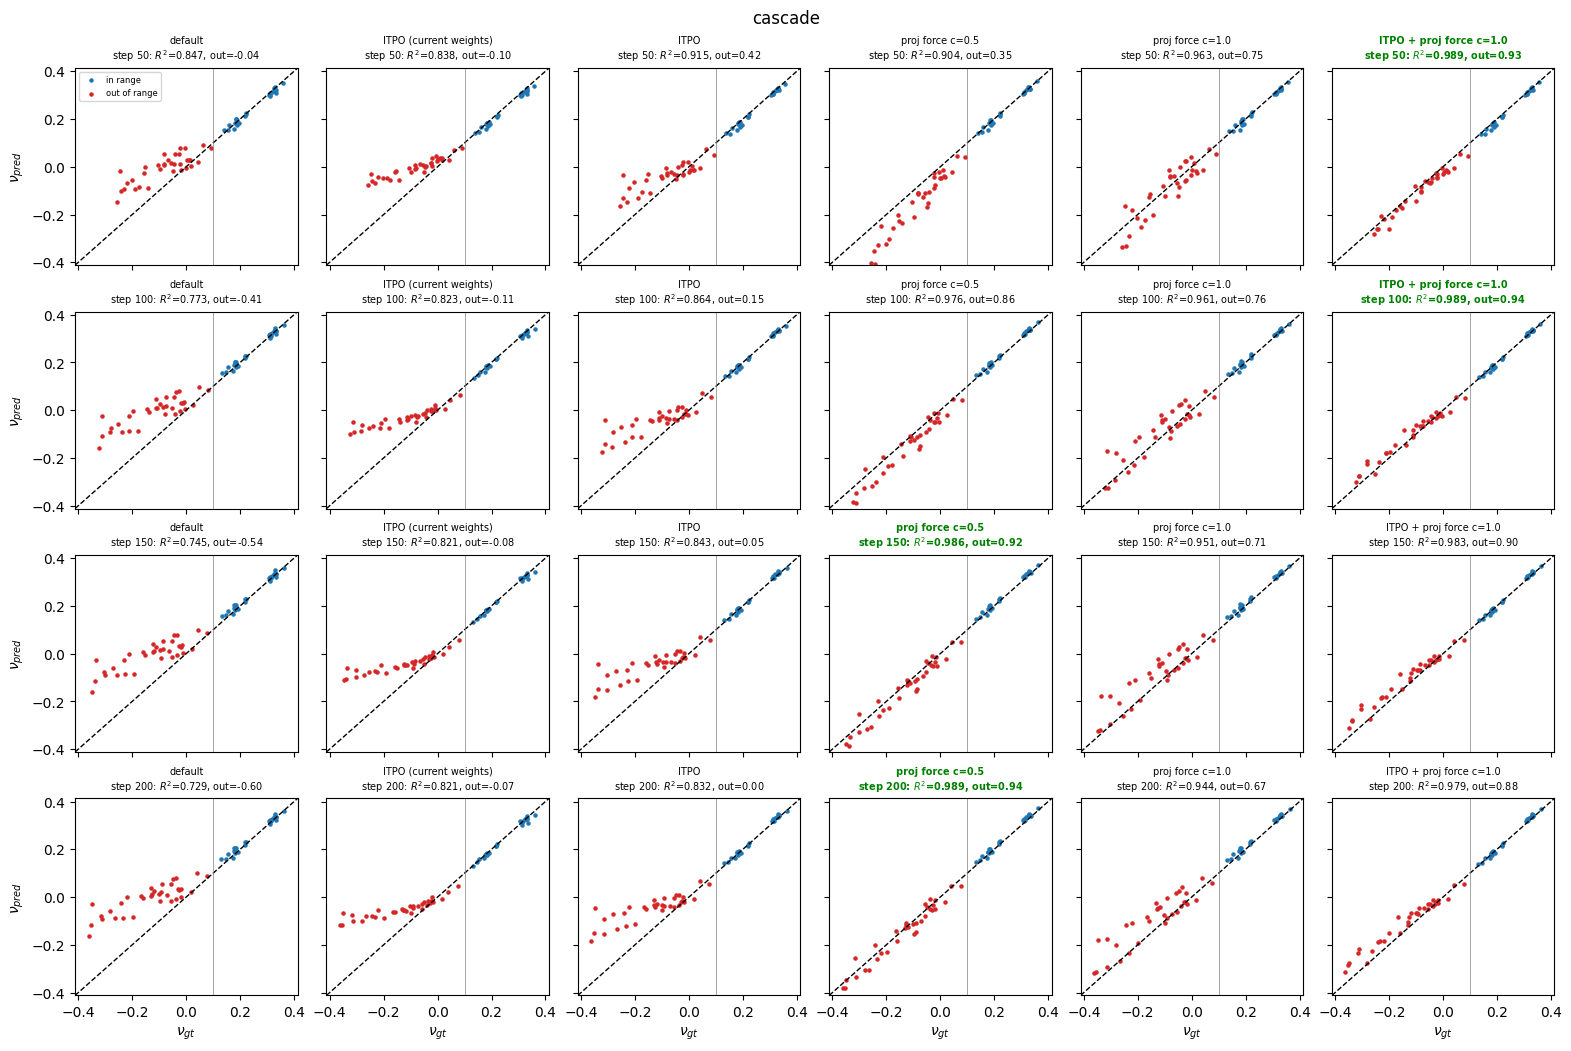

In [7]:
# nu_gt vs nu_pred at every recorded step; the method with the best R^2 (all sims) in each row gets a green title
scatter_methods = ["default", "ITPO (current weights)", "ITPO", "proj force c=0.5", "proj force c=1.0", "ITPO + proj force c=1.0"]
steps = sorted(long_df["step"].unique())

for model_name in models:
    model_df = long_df[long_df["model"] == model_name]
    methods = [m for m in scatter_methods if m in set(model_df["label"])]
    lims = (model_df["gt_p"].min() - 0.05, model_df["gt_p"].max() + 0.05)

    fig, ax = plt.subplots(len(steps), len(methods), figsize=(2.6 * len(methods), 2.6 * len(steps)), layout="constrained", sharex=True, sharey=True, squeeze=False)
    fig.suptitle(model_name)
    for row, step in enumerate(steps):
        r2_row = {}
        for col, label in enumerate(methods):
            d = model_df[(model_df["label"] == label) & (model_df["step"] == step)]
            inside = d["gt_p"] >= poisson_threshold
            a_ = ax[row][col]
            a_.plot(lims, lims, color="black", linewidth=1, linestyle="--")
            a_.axvline(poisson_threshold, color="grey", linewidth=0.5)
            a_.scatter(d["gt_p"][inside], d["pred_p"][inside], s=5, color="C0", label="in range")
            a_.scatter(d["gt_p"][~inside], d["pred_p"][~inside], s=5, color="C3", label="out of range")
            r2_all = r2_score(d["gt_p"], d["pred_p"])
            r2_out = r2_score(d["gt_p"][~inside], d["pred_p"][~inside])
            r2_row[col] = r2_all
            a_.set_title(f"{label}\nstep {step}: $R^2$={r2_all:.3f}, out={r2_out:.2f}", fontsize=7)
        best = max(r2_row, key=r2_row.get)
        ax[row][best].title.set_color("green")
        ax[row][best].title.set_fontweight("bold")
        ax[row][0].set_ylabel(r"$\nu_{pred}$")
    for col in range(len(methods)):
        ax[-1][col].set_xlabel(r"$\nu_{gt}$")
    ax[0][0].set_xlim(lims)
    ax[0][0].set_ylim(lims)
    ax[0][0].legend(fontsize=6)
    plt.show()

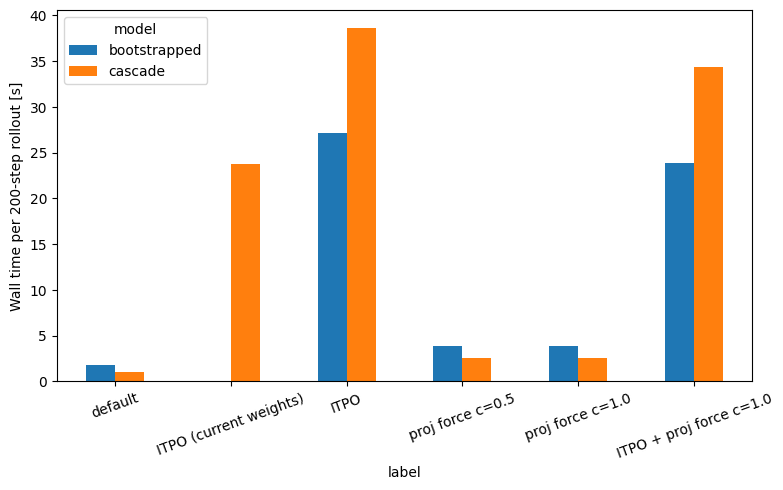

In [13]:
times = long_df[long_df["label"].isin(main_methods)].groupby(["model", "label"])["time"].mean().unstack("model")
times = times.reindex(main_methods)
ax = times.plot.bar(figsize=(8, 5), rot=20) # logy=True,
ax.set_ylabel(f"Wall time per {long_df['step'].max()}-step rollout [s]")
plt.tight_layout()
plt.show()

## Differentiability of the force projection (STE, IFT)

`ste(refine)` in `constraint_projection_benchmark.py` keeps the projected acceleration in the forward pass and treats the projection as identity in the backward pass, as `physical_inference_step_STE` does for ITPO.
`make_refine_force_ift(tau)` keeps the same forward pass, and its backward is the implicit derivative of the min-norm projection onto the active force constraints, $\partial a^* / \partial a_{nn} = I - J^\top (J J^\top)^{-1} J$ with $J = \partial F_{active} / \partial a$, solved by 10 CG iterations as `ImplicitPhysicsRefinement` does for ITPO.
`constrained_rollout(..., grad=True)` keeps the autograd graph through the rollout. The check: $\partial \nu / \partial k$ after a short cascade rollout, with the bond stiffnesses $k$ as the design variable.

In [ ]:
import constraint_projection_benchmark as cpb

sim = test_data[0]
steps = 10
config = barostat_parameters.node_optimizated
delta_x = (sim[4].box_tensor[0] - sim[3].box_tensor[0]).item()
refine = cpb.make_refine_force(tau / 3)  # 0.5x the envelope, tight enough for the projection to be active


def poisson_ratio(stiffness, refine, grad):
    start = sim[0].clone().to(device)
    start.edge_attr = torch.column_stack([start.edge_attr[:, :3], stiffness])
    rollout = cpb.constrained_rollout(cascade, [start], steps, config, delta_x, 0.0, start.edge_attr[:, -2], refine, grad=grad)
    return calc_p_ratio_box_tensor(rollout)


k = sim[0].edge_attr[:, 3].to(device).requires_grad_(True)
nu_ste = poisson_ratio(k, cpb.ste(refine), grad=True)
(grad_ste,) = torch.autograd.grad(nu_ste, k)
# Without STE the gradient still reaches k through the integrator and barostat, but not through the GNN
(grad_no_ste,) = torch.autograd.grad(poisson_ratio(k, refine, grad=True), k)
nu_ift = poisson_ratio(k, cpb.make_refine_force_ift(tau / 3), grad=True)
(grad_ift,) = torch.autograd.grad(nu_ift, k)
nu_proj = poisson_ratio(k.detach(), refine, grad=False)
nu_default = poisson_ratio(k.detach(), cpb.no_refine, grad=False)

print(f"nu: default {nu_default.item():.6f}, proj {nu_proj.item():.6f}, proj + STE {nu_ste.item():.6f}, proj + IFT {nu_ift.item():.6f}")
print(f"|dnu/dk|: STE {grad_ste.norm().item():.3e}, no STE {grad_no_ste.norm().item():.3e}, cosine {torch.cosine_similarity(grad_ste, grad_no_ste, dim=0).item():.3f}")
print(f"|dnu/dk|: IFT {grad_ift.norm().item():.3e}, cosine with STE {torch.cosine_similarity(grad_ift, grad_ste, dim=0).item():.3f}")
assert not torch.isclose(nu_proj, nu_default), "projection is inactive, the test is vacuous"
assert torch.isclose(nu_ste, nu_proj, atol=1e-6), "STE changed the forward pass"
assert torch.isclose(nu_ift, nu_proj, atol=1e-6), "IFT changed the forward pass"
assert torch.isfinite(grad_ste).all() and grad_ste.abs().sum() > 0, "no STE gradient through the projected rollout"
assert torch.isfinite(grad_ift).all() and grad_ift.abs().sum() > 0, "no IFT gradient through the projected rollout"
assert not torch.allclose(grad_ste, grad_no_ste), "STE adds no gradient through the GNN"

## Inverse design: force projection vs. ITPO

The two-style optimization from `gnn_optimization/cascade_itpo_optimization.ipynb`: node displacements and bond stiffnesses optimized jointly with Adam, with distance and angle penalties. It is run with five differentiable cascade rollouts:
- **default**: no refinement
- **proj STE** / **proj IFT**: force projection at $0.5\times$ the envelope, the best margin in the long-rollout study, differentiated by straight-through estimation or through the implicit function theorem
- **ITPO STE** / **ITPO IFT**: ITPO with the HEAD weights (`CASCADE_ITPO_WEIGHTS`), differentiated by straight-through estimation or exactly through the implicit function theorem

Every method runs for a fixed number of epochs; `optimize`, `bootstrapped_rollout` and the LAMMPS check live in `inverse_design_benchmark.py`.
The starting network is the test network with the highest $\nu$. Every optimized network is checked by a LAMMPS compression to 1% strain, the protocol of the training data.

In [2]:
from inverse_design_benchmark import P_TARGET, ROLLOUT_STEPS, bootstrapped_rollout, lammps_box_trajectory, optimize

In [3]:
from ift import specialized_rollout_cascade_implicit
from utils import specialized_rollout_cascade_STE

p_target, rollout_steps = P_TARGET, ROLLOUT_STEPS
epochs = 50

sim = max(test_data, key=calc_p_ratio_box_tensor)
graph = sim[0].clone().to(device)
config = barostat_parameters.node_optimizated
delta_x = (sim[4].box_tensor[0] - sim[3].box_tensor[0]).item()
rollouts = {  # tau is 1.5x the envelope
    "default": lambda g: cpb.constrained_rollout(cascade, [g], rollout_steps, config, delta_x, 0.0, g.edge_attr[:, -2], cpb.no_refine, grad=True),
    "proj STE": lambda g: cpb.constrained_rollout(cascade, [g], rollout_steps, config, delta_x, 0.0, g.edge_attr[:, -2], cpb.ste(cpb.make_refine_force(tau / 3)), grad=True),
    "proj IFT": lambda g: cpb.constrained_rollout(cascade, [g], rollout_steps, config, delta_x, 0.0, g.edge_attr[:, -2], cpb.make_refine_force_ift(tau / 3), grad=True),
    "ITPO STE": lambda g: specialized_rollout_cascade_STE(g, cascade, config, delta_x, CASCADE_ITPO_WEIGHTS, rollout_steps, device),
    "ITPO IFT": lambda g: specialized_rollout_cascade_implicit(g, cascade, config, delta_x, None, CASCADE_ITPO_WEIGHTS, rollout_steps, device),
}

print(f"GT nu over {len(sim)} frames: {calc_p_ratio_box_tensor(sim):.3f}")
design_results = {}
for name, rollout in rollouts.items():
    result, elapsed = cpb.timed(lambda: optimize(graph, rollout, epochs))
    design_results[name] = result | {"time": elapsed}
    print(f"{name:<10} | GNN nu {result['p'][0]:.3f} -> {result['p'][-1]:.3f}, {elapsed:.0f} s")

NameError: name 'test_data' is not defined

In [ ]:
def check_with_lammps(results, check_dir):
    trajs = {"original": lammps_box_trajectory(graph, os.path.join(check_dir, "original"))}
    for name, result in results.items():
        trajs[name] = lammps_box_trajectory(result["graph"], os.path.join(check_dir, name.replace(" ", "_")))
    for name, traj in trajs.items():
        predicted = f", GNN {results[name]['p'][-1]:.3f}" if name in results else ""
        print(f"{name:<10} | LAMMPS nu at 1% strain {calc_p_ratio_box_tensor(traj):.3f}{predicted}")
    return trajs


lammps_trajs = check_with_lammps(design_results, os.path.abspath("check/force_projection"))

In [ ]:
def plot_design_comparison(results, trajs, model_name):
    fig, ax = plt.subplots(1, 3, figsize=(14, 3.6), layout="constrained")
    fig.suptitle(model_name)
    x = np.arange(len(results))
    for i, (name, result) in enumerate(results.items()):
        ax[0].plot(result["p"], marker="o", markersize=3, color=f"C{i}", label=name)
    for i, (name, traj) in enumerate(trajs.items()):
        color = "black" if name == "original" else f"C{i - 1}"
        ax[1].plot(range(2, len(traj)), [calc_p_ratio_box_tensor(traj, j).item() for j in range(2, len(traj))], color=color, label=name)
    ax[0].axhline(p_target, color="black", linestyle="--", linewidth=1)
    ax[0].set_xlabel("Optimization epoch")
    ax[0].set_ylabel(rf"GNN $\nu$ at {rollout_steps} steps")
    ax[0].legend()
    ax[1].set_xlabel("LAMMPS dump step")
    ax[1].set_ylabel(r"LAMMPS $\nu$")
    ax[1].legend()
    ax[2].bar(x - 0.2, [r["p"][-1] for r in results.values()], width=0.4, label="GNN")
    ax[2].bar(x + 0.2, [calc_p_ratio_box_tensor(trajs[n]).item() for n in results], width=0.4, label="LAMMPS")
    ax[2].axhline(calc_p_ratio_box_tensor(trajs["original"]).item(), color="black", linewidth=1, label="original, LAMMPS")
    ax[2].set_xticks(x, list(results))
    ax[2].set_ylabel(r"Final $\nu$")
    ax[2].legend()
    plt.show()

    fig, ax = plt.subplots(1, len(results), figsize=(3.5 * len(results), 3), layout="constrained", sharey=True)
    bins = np.linspace(0, max(r["graph"].edge_attr[:, -1].max().item() for r in results.values()), 31)
    for a_, (name, result) in zip(ax, results.items()):
        a_.hist(graph.edge_attr[:, -1].cpu(), bins=bins, alpha=0.7, density=True, edgecolor="black", linewidth=0.3, label="Original")
        a_.hist(result["graph"].edge_attr[:, -1].cpu(), bins=bins, alpha=0.7, density=True, edgecolor="black", linewidth=0.3, label="Optimized")
        a_.set_title(name)
        a_.set_xlabel("Bond stiffness")
    ax[0].legend()
    plt.show()


plot_design_comparison(design_results, lammps_trajs, "Simulator cascade")

### Bootstrapped GNN simulator

The same optimization of the same network with the bootstrapped simulator (history 3): a differentiable MD bootstrap of `history` dump periods without Langevin noise, as inside the ITPO rollouts, followed by `rollout_steps` GNN steps.
ITPO uses `itpo_weights.get_params(ModelType.GNNModel, ...)`, as in the long-rollout study.

In [ ]:
from ift import specialized_rollout_implicit
from utils import specialized_rollout_STE

# Compute dumping period (N MD steps in 1 dump step)
sim_strain = (sim[1].box.x - sim[-1].box.x) / sim[0].box.x
dump_period = int(int(sim_strain / 1e-5 / 0.01) / len(sim)) + 1
boot_config = deepcopy(barostat_parameters.node_optimizated)
boot_config["default_skip"] = dump_period
md_steps = dump_period * history + 1
boot_weights = itpo_weights.get_params(ModelType.GNNModel, dataset_type)

boot_rollouts = {  # the ITPO rollouts run rollout_steps + 1 GNN steps
    "default": lambda g: bootstrapped_rollout(g, gnn_simulator, cpb.no_refine, boot_config, history, rollout_steps),
    "proj STE": lambda g: bootstrapped_rollout(g, gnn_simulator, cpb.ste(cpb.make_refine_force(tau / 3)), boot_config, history, rollout_steps),
    "proj IFT": lambda g: bootstrapped_rollout(g, gnn_simulator, cpb.make_refine_force_ift(tau / 3), boot_config, history, rollout_steps),
    "ITPO STE": lambda g: specialized_rollout_STE(g, gnn_simulator, history, boot_config, boot_weights, md_steps, rollout_steps - 1, device),
    "ITPO IFT": lambda g: specialized_rollout_implicit(g, gnn_simulator, history, boot_config, None, boot_weights, md_steps, rollout_steps - 1, device),
}

boot_results = {}
for name, rollout in boot_rollouts.items():
    result, elapsed = cpb.timed(lambda: optimize(graph, rollout, epochs))
    boot_results[name] = result | {"time": elapsed}
    print(f"{name:<10} | GNN nu {result['p'][0]:.3f} -> {result['p'][-1]:.3f}, {elapsed:.0f} s")

In [ ]:
boot_lammps_trajs = check_with_lammps(boot_results, os.path.abspath("check/force_projection_bootstrapped"))
plot_design_comparison(boot_results, boot_lammps_trajs, "Bootstrapped GNN simulator")

## Inverse design on several networks (force projection)

Computed headlessly by `inverse_design_benchmark.py` (one directory per model in `inverse_design_results/`); this section only loads and plots.
The 5 test networks with the highest $\nu$, 50 epochs of the same optimization for every method, no ITPO. `lammps_p` is the LAMMPS $\nu$ at 1% strain, `lammps_p_last_frame` at the frame the GNN objective is evaluated on.

method                                  default  proj STE  proj IFT
model        network lammps_p_original                             
cascade      1       0.403986            -0.047    -0.110    -0.040
             20      0.364623             0.001    -0.122    -0.125
             6       0.360951             0.038    -0.192    -0.106
             17      0.360527            -0.026    -0.101    -0.261
             29      0.358366             0.056    -0.212    -0.122
bootstrapped 1       0.403986            -0.027    -0.097    -0.118
             20      0.364623            -0.055    -0.123    -0.176
             6       0.360951             0.061    -0.106    -0.120
             17      0.360527             0.013    -0.258    -0.099
             29      0.358366            -0.018    -0.180    -0.111

gnn_p        lammps_p_last_frame        lammps_p  \
                        mean    std                mean    std     mean   
model        method                                                       
cascade      default  -0.044  0.131               0.074  0.023    0.004   
             proj STE -0.277  0.029               0.011  0.030   -0.147   
             proj IFT -0.291  0.010               0.003  0.031   -0.131   
bootstrapped default  -0.296  0.007               0.042  0.023   -0.005   
             proj STE -0.290  0.008              -0.033  0.021   -0.153   
             proj IFT -0.280  0.040              -0.011  0.045   -0.125   

                                 time         
                         std     mean    std  
model        method                           
cascade      default   0.043    8.694  0.452  
             proj STE  0.051   16.385  0.879  
             proj IFT  0.080   56.197  1.429  
bootstrapped default   0.044   62.623  4.150  
             proj STE  0.067   67.879  3.848  
             proj IFT  0.030  153.383  5.357

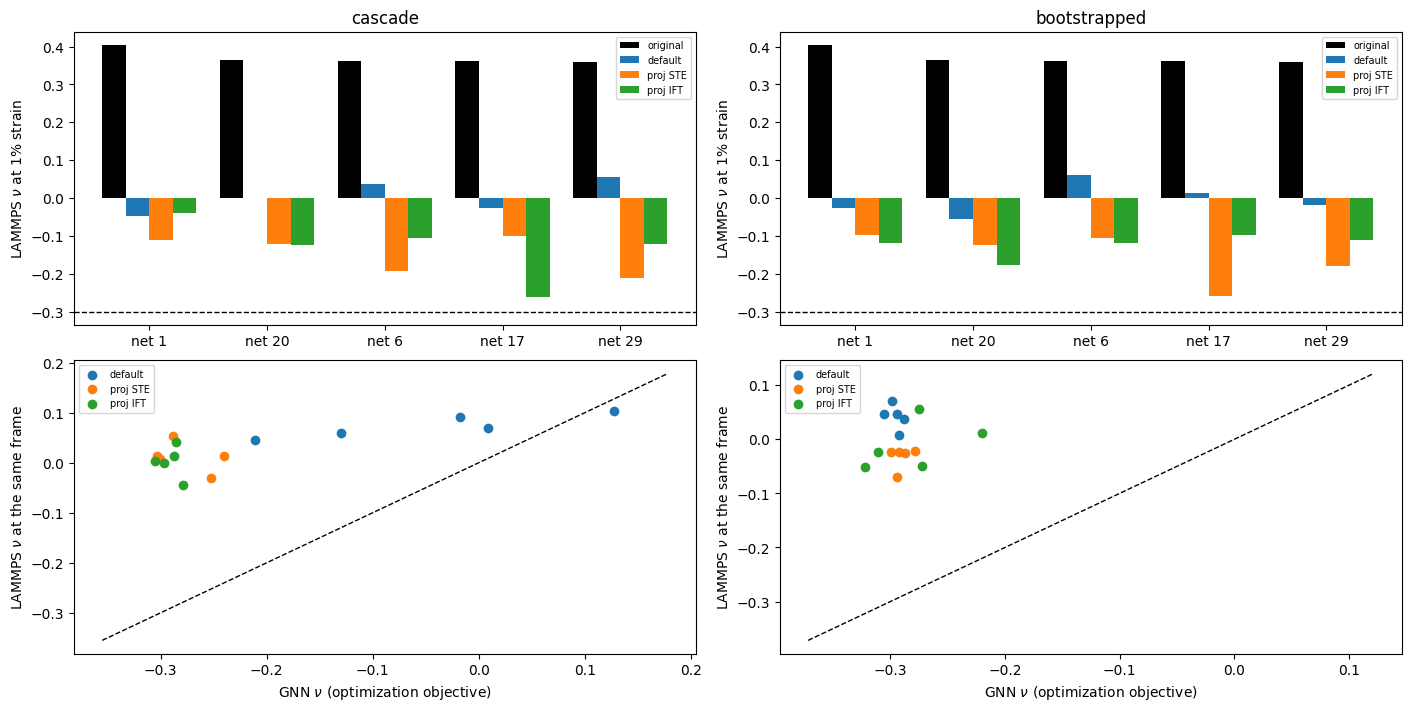

In [4]:
from inverse_design_benchmark import P_TARGET

results_dir = Path("inverse_design_results")

frames = []
for model_name in ("cascade", "bootstrapped"):
    path = results_dir / model_name / "summary.csv"
    if not path.exists():
        warnings.warn(f"{path} is missing, skipping {model_name}.")
        continue
    frames.append(pd.read_csv(path))
id_df = pd.concat(frames, ignore_index=True)
methods = list(id_df["method"].unique())

display(id_df.pivot_table(index=["model", "network", "lammps_p_original"], columns="method", values="lammps_p", sort=False)[methods].round(3))
display(id_df.groupby(["model", "method"], sort=False)[["gnn_p", "lammps_p_last_frame", "lammps_p", "time"]].agg(["mean", "std"]).round(3))

models = list(id_df["model"].unique())
fig, ax = plt.subplots(2, len(models), figsize=(7 * len(models), 7), layout="constrained", squeeze=False)
for col, model_name in enumerate(models):
    d = id_df[id_df["model"] == model_name]
    networks = list(d["network"].unique())
    x = np.arange(len(networks))
    width = 0.8 / (len(methods) + 1)
    ax[0][col].bar(x - 0.4 + width / 2, d.groupby("network")["lammps_p_original"].first().loc[networks], width, color="black", label="original")
    for i, method in enumerate(methods):
        m = d[d["method"] == method].set_index("network").loc[networks]
        ax[0][col].bar(x - 0.4 + width * (i + 1.5), m["lammps_p"], width, color=f"C{i}", label=method)
        ax[1][col].scatter(m["gnn_p"], m["lammps_p_last_frame"], color=f"C{i}", label=method)
    ax[0][col].axhline(P_TARGET, color="black", linestyle="--", linewidth=1)
    ax[0][col].set_xticks(x, [f"net {n}" for n in networks])
    ax[0][col].set_ylabel(r"LAMMPS $\nu$ at 1% strain")
    ax[0][col].set_title(model_name)
    ax[0][col].legend(fontsize=7)
    lims = (min(d["gnn_p"].min(), d["lammps_p_last_frame"].min()) - 0.05, max(d["gnn_p"].max(), d["lammps_p_last_frame"].max()) + 0.05)
    ax[1][col].plot(lims, lims, color="black", linestyle="--", linewidth=1)
    ax[1][col].set_xlabel(r"GNN $\nu$ (optimization objective)")
    ax[1][col].set_ylabel(r"LAMMPS $\nu$ at the same frame")
    ax[1][col].legend(fontsize=7)
plt.show()

## Harmonic-residual simulator

Computed headlessly by `residual_simulator_training.py` (model in `simulator_residual.py`); this section only loads and plots.
The bootstrapped simulator (history 3) predicts a correction to one explicit step of the harmonic bond forces, $a = F_{harm}(x_t) / (m \cdot mvv2e) \, \Delta t^2 + \text{correction}$.
All models are trained on the $\nu \geq 0.1$ training sims and rolled out from the first 4 ground-truth frames of every test sim without refinement:
- **plain OST** / **residual OST**: the same OST loop of `gnn_simulator_training.ipynb`
- **benchmark MST**: the MST checkpoint used in the benchmarks (`new_trained_models/.../MST/checkpoint_epoch_120.pt`)
- **harmonic only**: the harmonic step without a network
- **residual MST**: the last scored checkpoint of the MST run (stopped at epoch 110 of 150)

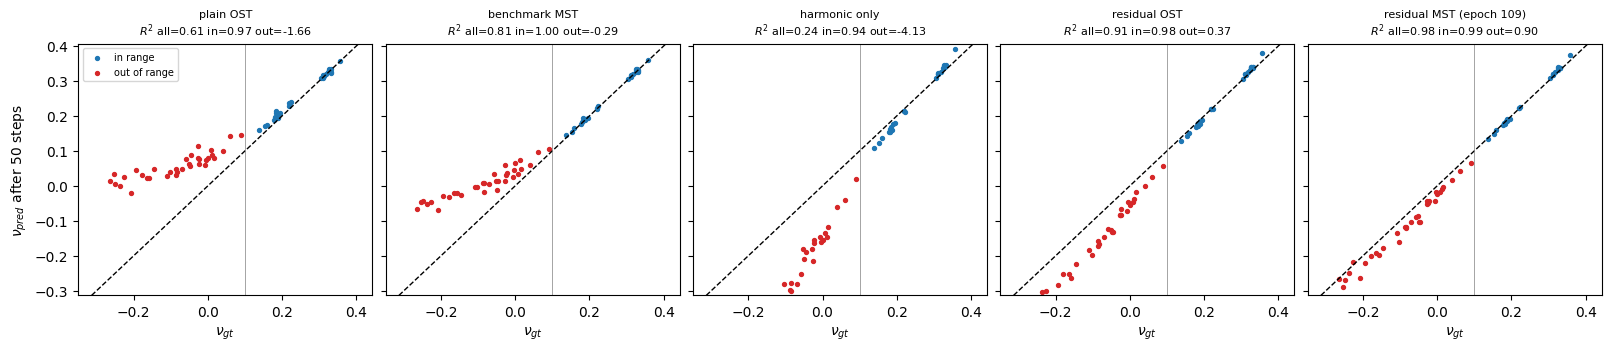

In [2]:
residual_dir = Path("residual_simulator")
rollout_step = 50
poisson_threshold = 0.1  # all models were trained on nu >= 0.1 only

sources = {
    "plain OST": residual_dir / "plain" / "rollouts.csv",
    "benchmark MST": residual_dir / "mst_reference" / "rollouts.csv",
    "harmonic only": residual_dir / "harmonic_only" / "rollouts.csv",
    "residual OST": residual_dir / "residual" / "rollouts.csv",
    "residual MST": residual_dir / "residual_mst" / "checkpoint_rollouts.csv",
}
residual_rollouts = {}
for name, path in sources.items():
    if not path.exists():
        warnings.warn(f"{path} is missing, skipping {name}.")
        continue
    df = pd.read_csv(path)
    if "epoch" in df:
        name = f"{name} (epoch {df['epoch'].max()})"
        df = df[df["epoch"] == df["epoch"].max()]
    residual_rollouts[name] = df[df["step"] == rollout_step]

fig, ax = plt.subplots(1, len(residual_rollouts), figsize=(3.2 * len(residual_rollouts), 3.4), layout="constrained", sharex=True, sharey=True, squeeze=False)
gt_all = pd.concat(residual_rollouts.values())["gt_p"]
lims = (gt_all.min() - 0.05, gt_all.max() + 0.05)
for a_, (name, d) in zip(ax[0], residual_rollouts.items()):
    inside = d["gt_p"] >= poisson_threshold
    a_.plot(lims, lims, color="black", linewidth=1, linestyle="--")
    a_.axvline(poisson_threshold, color="grey", linewidth=0.5)
    a_.scatter(d["gt_p"][inside], d["pred_p"][inside], s=8, color="C0", label="in range")
    a_.scatter(d["gt_p"][~inside], d["pred_p"][~inside], s=8, color="C3", label="out of range")
    r2_all = r2_score(d["gt_p"], d["pred_p"])
    r2_in = r2_score(d["gt_p"][inside], d["pred_p"][inside])
    r2_out = r2_score(d["gt_p"][~inside], d["pred_p"][~inside])
    a_.set_title(f"{name}\n$R^2$ all={r2_all:.2f} in={r2_in:.2f} out={r2_out:.2f}", fontsize=8)
    a_.set_xlabel(r"$\nu_{gt}$")
ax[0][0].set_ylabel(rf"$\nu_{{pred}}$ after {rollout_step} steps")
ax[0][0].set_ylim(lims)
ax[0][0].legend(fontsize=7)
plt.show()